In [ ]:
!pip install -U sentence-transformers scikit-learn pandas numpy
!pip install numpy
!pip install scipy

In [ ]:
import pandas as pd
import numpy as np
import time

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

In [ ]:
df = pd.read_csv("/content/multimodal_train.tsv", sep='\t')

df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


In [ ]:
modelo = SentenceTransformer("BAAI/bge-m3")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

### 1. Preparar os dados e gerar embeddings

Primeiro, vamos selecionar a coluna de texto que queremos usar para gerar os embeddings. A coluna `clean_title` parece ser uma boa opção. Em seguida, usaremos o modelo `modelo` para transformar esses textos em vetores numéricos.

In [ ]:
# Selecionar a coluna de texto e a coluna de rótulo
# Limitar o número de amostras para 5000
num_samples = 5000
temp_df = df.dropna(subset=['clean_title'])
text_data = temp_df['clean_title'].tolist()[:num_samples]
labels = temp_df['2_way_label'].values[:num_samples]

print(f"Número de textos para embedding: {len(text_data)}")
print(f"Número de rótulos: {len(labels)}")

Número de textos para embedding: 5000
Número de rótulos: 5000


Agora, vamos gerar os embeddings para os textos usando o modelo `modelo`. Este processo pode levar algum tempo, dependendo do tamanho do seu dataset.

In [ ]:
print("Gerando embeddings...")
start_time = time.time()
embeddings = modelo.encode(text_data, show_progress_bar=True)
end_time = time.time()
print(f"Embeddings gerados em {end_time - start_time:.2f} segundos.")

print(f"Formato dos embeddings: {embeddings.shape}")

Gerando embeddings...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Embeddings gerados em 717.13 segundos.
Formato dos embeddings: (5000, 1024)


### 2. Dividir os dados em conjuntos de treinamento e teste

Para treinar e avaliar o modelo de classificação, precisamos dividir nossos embeddings e rótulos em conjuntos de treinamento e teste. Usaremos o `train_test_split` do scikit-learn.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.2, random_state=42, stratify=labels)

print(f"Tamanho do conjunto de treinamento (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho dos rótulos de treinamento (y_train): {y_train.shape}")
print(f"Tamanho dos rótulos de teste (y_test): {y_test.shape}")

Tamanho do conjunto de treinamento (X_train): (4000, 1024)
Tamanho do conjunto de teste (X_test): (1000, 1024)
Tamanho dos rótulos de treinamento (y_train): (4000,)
Tamanho dos rótulos de teste (y_test): (1000,)


### 3. Treinar o Modelo de Classificação

Agora que temos os dados divididos, podemos treinar um modelo de Regressão Logística para classificar as fake news.

In [ ]:
print("Treinando o modelo de Regressão Logística...")
start_time = time.time()
classifier = LogisticRegression(max_iter=1000, random_state=42) # Aumentar max_iter para garantir convergência
classifier.fit(X_train, y_train)
end_time = time.time()
print(f"Modelo treinado em {end_time - start_time:.2f} segundos.")
print("Modelo de Regressão Logística treinado com sucesso!")

Treinando o modelo de Regressão Logística...
Modelo treinado em 0.25 segundos.
Modelo de Regressão Logística treinado com sucesso!


### 4. Avaliar o Modelo de Classificação

Vamos avaliar o desempenho do modelo usando as previsões no conjunto de teste e algumas métricas de classificação.

In [ ]:
print("Fazendo previsões no conjunto de teste...")
y_pred = classifier.predict(X_test)

print("Avaliação do Modelo:")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score (média ponderada): {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Fazendo previsões no conjunto de teste...
Avaliação do Modelo:
Acurácia: 0.8170
F1-Score (média ponderada): 0.8171

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       588
           1       0.78      0.78      0.78       412

    accuracy                           0.82      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.82      0.82      0.82      1000



### 5. Visualizar a Matriz de Confusão

Uma matriz de confusão é uma ótima ferramenta para visualizar o desempenho de um algoritmo de classificação. Ela nos ajuda a entender onde o modelo está acertando e errando.

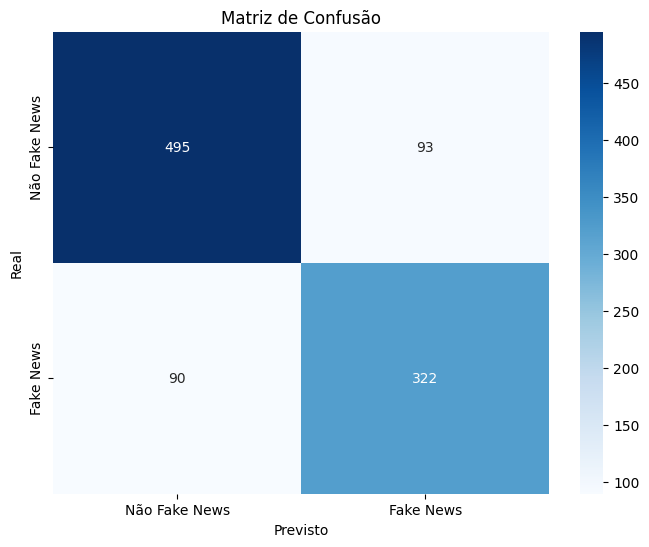

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Gerar a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Fake News', 'Fake News'],
            yticklabels=['Não Fake News', 'Fake News'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

### 6. Otimização de Hiperparâmetros com GridSearchCV

Agora vamos usar o `GridSearchCV` para encontrar o melhor valor para o hiperparâmetro `C` do nosso modelo de Regressão Logística. O `C` controla a força da regularização (quanto menor `C`, mais forte a regularização).

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir o range de valores para C a serem testados
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Criar o modelo de Regressão Logística
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Configurar o GridSearchCV
grid_search = GridSearchCV(logistic_model, param_grid, cv=3, scoring='f1_weighted', verbose=1, n_jobs=-1)

print("Iniciando GridSearchCV para encontrar o melhor valor de C...")
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()

print(f"GridSearchCV concluído em {end_time - start_time:.2f} segundos.")

# Exibir os melhores hiperparâmetros e a melhor pontuação
print(f"Melhores hiperparâmetros: {grid_search.best_params_}")
print(f"Melhor F1-Score (ponderado) no conjunto de validação: {grid_search.best_score_:.4f}")

# O melhor modelo encontrado está disponível em grid_search.best_estimator_
best_classifier = grid_search.best_estimator_


Iniciando GridSearchCV para encontrar o melhor valor de C...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
GridSearchCV concluído em 11.92 segundos.
Melhores hiperparâmetros: {'C': 1}
Melhor F1-Score (ponderado) no conjunto de validação: 0.8036


Agora, vamos avaliar o modelo com os melhores hiperparâmetros encontrados pelo `GridSearchCV` no conjunto de teste.

In [ ]:
print("Fazendo previsões com o melhor modelo no conjunto de teste...")
y_pred_best = best_classifier.predict(X_test)

print("Avaliação do Melhor Modelo (GridSearchCV):")
print(f"Acurácia: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1-Score (média ponderada): {f1_score(y_test, y_pred_best, average='weighted'):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_best))

Fazendo previsões com o melhor modelo no conjunto de teste...
Avaliação do Melhor Modelo (GridSearchCV):
Acurácia: 0.8170
F1-Score (média ponderada): 0.8171

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       588
           1       0.78      0.78      0.78       412

    accuracy                           0.82      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.82      0.82      0.82      1000



### 7. Experimentar com Random Forest Classifier

Agora, vamos tentar um modelo de Random Forest para ver se conseguimos melhorar o desempenho de classificação usando os mesmos embeddings.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Treinando o modelo Random Forest...")
start_time = time.time()

# Criar e treinar o modelo Random Forest
# Usaremos um número razoável de estimadores (árvores) e um random_state para reprodutibilidade
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_train)

end_time = time.time()
print(f"Modelo Random Forest treinado em {end_time - start_time:.2f} segundos.")
print("Modelo Random Forest treinado com sucesso!")

Treinando o modelo Random Forest...
Modelo Random Forest treinado em 6.17 segundos.
Modelo Random Forest treinado com sucesso!


### 8. Avaliar o Modelo Random Forest

Vamos avaliar o desempenho do Random Forest no conjunto de teste.

In [ ]:
print("Fazendo previsões no conjunto de teste com Random Forest...")
y_pred_rf = rf_classifier.predict(X_test)

print("Avaliação do Modelo Random Forest:")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score (média ponderada): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print("\nRelatório de Classificação Random Forest:")
print(classification_report(y_test, y_pred_rf))

Fazendo previsões no conjunto de teste com Random Forest...
Avaliação do Modelo Random Forest:
Acurácia: 0.7870
F1-Score (média ponderada): 0.7848

Relatório de Classificação Random Forest:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       588
           1       0.77      0.69      0.73       412

    accuracy                           0.79      1000
   macro avg       0.78      0.77      0.78      1000
weighted avg       0.79      0.79      0.78      1000



### 9. Visualizar a Matriz de Confusão para Random Forest

Para uma análise visual do desempenho do Random Forest.

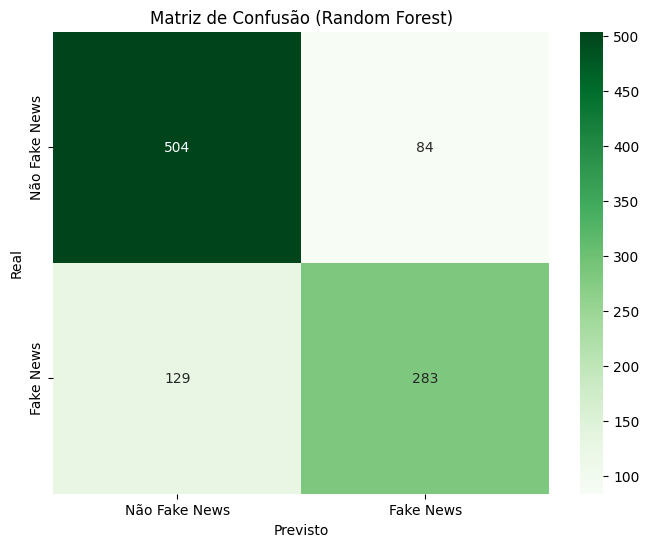

In [ ]:
# Gerar a matriz de confusão para o Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Não Fake News', 'Fake News'],
            yticklabels=['Não Fake News', 'Fake News'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Random Forest)')
plt.show()

### 10. Otimização de Hiperparâmetros do Random Forest com GridSearchCV

Agora vamos otimizar o modelo Random Forest usando `GridSearchCV`. Focaremos em parâmetros importantes como o número de árvores (`n_estimators`) e a profundidade máxima de cada árvore (`max_depth`).

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definir o range de valores para os hiperparâmetros a serem testados
param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Número de árvores na floresta
    'max_depth': [None, 10, 20],   # Profundidade máxima da árvore (None = ilimitado)
    'min_samples_leaf': [1, 5]     # Número mínimo de amostras necessárias em um nó folha
}

# Criar o modelo Random Forest
rf_model_grid = RandomForestClassifier(random_state=42, n_jobs=-1)

# Configurar o GridSearchCV
grid_search_rf = GridSearchCV(rf_model_grid, param_grid_rf, cv=3, scoring='f1_weighted', verbose=1, n_jobs=-1)

print("Iniciando GridSearchCV para encontrar os melhores hiperparâmetros para o Random Forest...")
start_time_rf_grid = time.time()
grid_search_rf.fit(X_train, y_train)
end_time_rf_grid = time.time()

print(f"GridSearchCV (Random Forest) concluído em {end_time_rf_grid - start_time_rf_grid:.2f} segundos.")

# Exibir os melhores hiperparâmetros e a melhor pontuação
print(f"Melhores hiperparâmetros (Random Forest): {grid_search_rf.best_params_}")
print(f"Melhor F1-Score (ponderado) no conjunto de validação (Random Forest): {grid_search_rf.best_score_:.4f}")

# O melhor modelo encontrado está disponível em grid_search_rf.best_estimator_
best_rf_classifier = grid_search_rf.best_estimator_

Iniciando GridSearchCV para encontrar os melhores hiperparâmetros para o Random Forest...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
GridSearchCV (Random Forest) concluído em 254.20 segundos.
Melhores hiperparâmetros (Random Forest): {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Melhor F1-Score (ponderado) no conjunto de validação (Random Forest): 0.7822


### 11. Avaliar o Melhor Modelo Random Forest (GridSearchCV)

Agora, vamos avaliar o modelo Random Forest com os melhores hiperparâmetros encontrados pelo `GridSearchCV` no conjunto de teste.

In [ ]:
print("Fazendo previsões com o melhor modelo Random Forest no conjunto de teste...")
y_pred_best_rf = best_rf_classifier.predict(X_test)

print("Avaliação do Melhor Modelo Random Forest (GridSearchCV):")
print(f"Acurácia: {accuracy_score(y_test, y_pred_best_rf):.4f}")
print(f"F1-Score (média ponderada): {f1_score(y_test, y_pred_best_rf, average='weighted'):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_best_rf))

Fazendo previsões com o melhor modelo Random Forest no conjunto de teste...
Avaliação do Melhor Modelo Random Forest (GridSearchCV):
Acurácia: 0.7890
F1-Score (média ponderada): 0.7869

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       588
           1       0.77      0.69      0.73       412

    accuracy                           0.79      1000
   macro avg       0.79      0.77      0.78      1000
weighted avg       0.79      0.79      0.79      1000



### 13. Experimentar com Support Vector Machine (SVM)

Vamos agora experimentar com um classificador SVM (Support Vector Machine) para ver como ele se comporta com os mesmos embeddings.

In [ ]:
from sklearn.svm import SVC

print("Treinando o modelo SVM...")
start_time = time.time()

# Criar e treinar o modelo SVM
# Usaremos um kernel linear como ponto de partida e um random_state para reprodutibilidade
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train, y_train)

end_time = time.time()
print(f"Modelo SVM treinado em {end_time - start_time:.2f} segundos.")
print("Modelo SVM treinado com sucesso!")

Treinando o modelo SVM...
Modelo SVM treinado em 7.11 segundos.
Modelo SVM treinado com sucesso!


### 14. Avaliar o Modelo SVM

Vamos avaliar o desempenho do SVM no conjunto de teste.

In [ ]:
print("Fazendo previsões no conjunto de teste com SVM...")
y_pred_svm = svm_classifier.predict(X_test)

print("Avaliação do Modelo SVM:")
print(f"Acurácia: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score (média ponderada): {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print("\nRelatório de Classificação SVM:")
print(classification_report(y_test, y_pred_svm))

Fazendo previsões no conjunto de teste com SVM...
Avaliação do Modelo SVM:
Acurácia: 0.8220
F1-Score (média ponderada): 0.8225

Relatório de Classificação SVM:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       588
           1       0.77      0.81      0.79       412

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



### 15. Visualizar a Matriz de Confusão para SVM

Para uma análise visual do desempenho do SVM.

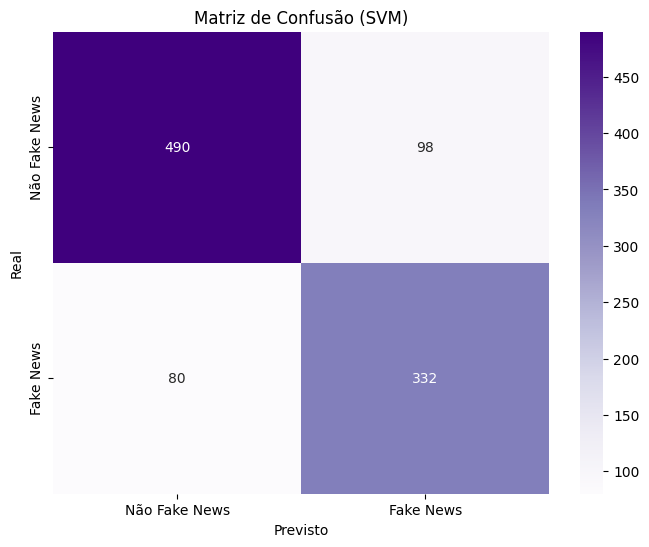

In [ ]:
# Gerar a matriz de confusão para o SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Não Fake News', 'Fake News'],
            yticklabels=['Não Fake News', 'Fake News'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (SVM)')
plt.show()

### 16. Otimização de Hiperparâmetros do SVM com GridSearchCV

Vamos otimizar o modelo SVM usando `GridSearchCV` para encontrar os melhores hiperparâmetros, como o parâmetro de regularização `C` e o tipo de `kernel`.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Definir o range de valores para os hiperparâmetros a serem testados
param_grid_svm = {
    'C': [0.1, 1, 10, 100],  # Parâmetro de regularização
    'kernel': ['linear', 'rbf'] # Tipos de kernel a testar
}

# Criar o modelo SVM
svm_model_grid = SVC(random_state=42)

# Configurar o GridSearchCV
grid_search_svm = GridSearchCV(svm_model_grid, param_grid_svm, cv=3, scoring='f1_weighted', verbose=1, n_jobs=-1)

print("Iniciando GridSearchCV para encontrar os melhores hiperparâmetros para o SVM...")
start_time_svm_grid = time.time()
grid_search_svm.fit(X_train, y_train)
end_time_svm_grid = time.time()

print(f"GridSearchCV (SVM) concluído em {end_time_svm_grid - start_time_svm_grid:.2f} segundos.")

# Exibir os melhores hiperparâmetros e a melhor pontuação
print(f"Melhores hiperparâmetros (SVM): {grid_search_svm.best_params_}")
print(f"Melhor F1-Score (ponderado) no conjunto de validação (SVM): {grid_search_svm.best_score_:.4f}")

# O melhor modelo encontrado está disponível em grid_search_svm.best_estimator_
best_svm_classifier = grid_search_svm.best_estimator_

Iniciando GridSearchCV para encontrar os melhores hiperparâmetros para o SVM...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
GridSearchCV (SVM) concluído em 140.99 segundos.
Melhores hiperparâmetros (SVM): {'C': 1, 'kernel': 'rbf'}
Melhor F1-Score (ponderado) no conjunto de validação (SVM): 0.8217


### 17. Avaliar o Melhor Modelo SVM (GridSearchCV)

Vamos avaliar o modelo SVM com os melhores hiperparâmetros encontrados pelo `GridSearchCV` no conjunto de teste.

In [ ]:
print("Fazendo previsões com o melhor modelo SVM no conjunto de teste...")
y_pred_best_svm = best_svm_classifier.predict(X_test)

print("Avaliação do Melhor Modelo SVM (GridSearchCV):")
print(f"Acurácia: {accuracy_score(y_test, y_pred_best_svm):.4f}")
print(f"F1-Score (média ponderada): {f1_score(y_test, y_pred_best_svm, average='weighted'):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_best_svm))

Fazendo previsões com o melhor modelo SVM no conjunto de teste...
Avaliação do Melhor Modelo SVM (GridSearchCV):
Acurácia: 0.8320
F1-Score (média ponderada): 0.8324

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       588
           1       0.79      0.82      0.80       412

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



### 19. Análise da Distribuição das Classes

Para entender melhor se os "0" estão sendo tratados como ruído, vamos primeiro verificar a distribuição das classes "0" e "1" no nosso conjunto de dados.

In [ ]:
import pandas as pd

# Converter o array de labels em uma Series do pandas para usar value_counts
labels_series = pd.Series(labels)

print("Distribuição das classes no dataset total:")
class_distribution = labels_series.value_counts(normalize=True) # normalize para mostrar proporções
display(class_distribution)

print("\nContagem absoluta das classes:")
class_counts = labels_series.value_counts()
display(class_counts)

# Verificar a distribuição no conjunto de treinamento e teste também
y_train_series = pd.Series(y_train)
y_test_series = pd.Series(y_test)

print("\nDistribuição das classes no conjunto de treinamento (y_train):")
display(y_train_series.value_counts(normalize=True))

print("\nDistribuição das classes no conjunto de teste (y_test):")
display(y_test_series.value_counts(normalize=True))

Distribuição das classes no dataset total:


0    0.5884
1    0.4116
Name: proportion, dtype: float64


Contagem absoluta das classes:


0    2942
1    2058
Name: count, dtype: int64


Distribuição das classes no conjunto de treinamento (y_train):


0    0.5885
1    0.4115
Name: proportion, dtype: float64


Distribuição das classes no conjunto de teste (y_test):


0    0.588
1    0.412
Name: proportion, dtype: float64

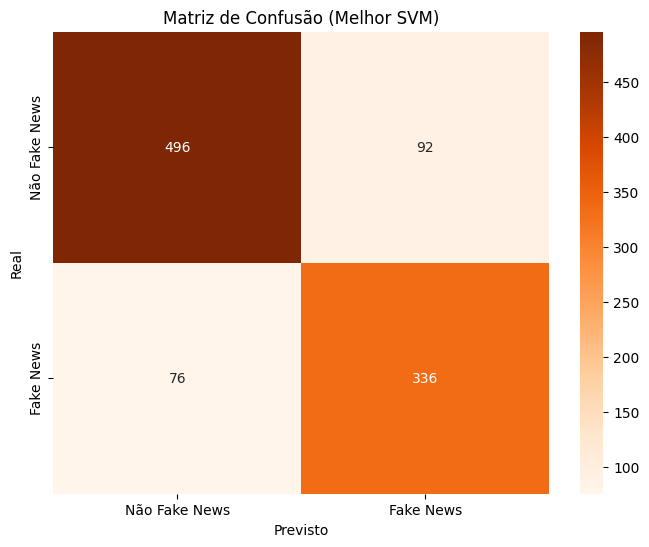

In [ ]:
# Gerar a matriz de confusão para o melhor SVM
cm_best_svm = confusion_matrix(y_test, y_pred_best_svm)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Não Fake News', 'Fake News'],
            yticklabels=['Não Fake News', 'Fake News'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Melhor SVM)')
plt.show()

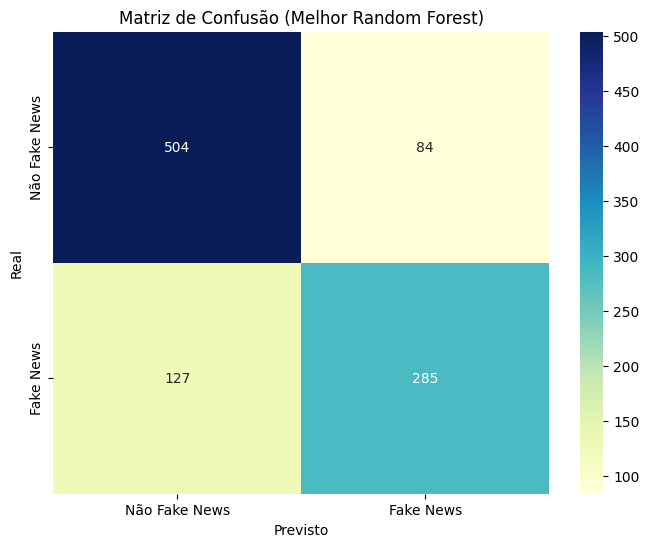

In [ ]:
# Gerar a matriz de confusão para o melhor Random Forest
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Não Fake News', 'Fake News'],
            yticklabels=['Não Fake News', 'Fake News'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Melhor Random Forest)')
plt.show()